In [1]:
import logfire
from psycopg.rows import dict_row
from psycopg_pool import AsyncConnectionPool

from src.agents.agentic.grader import GraderAgent
from src.agents.agentic.planner import PlannerAgent
from src.agents.agentic.query_expander import QueryExpander
from src.agents.agentic.query_rewriter import QueryRewriter
from src.agents.agentic.router import RouterAgent
from src.agents.agentic.synthesizer import SynthesizerAgent
from src.agents.graph.graph import compile_graph_with_postgres
from src.agents.graph.runner import GraphPipeline
from src.agents.memory.short_term import ShortTermMemoryManager
from src.agents.retrieval import RetrievalAgent
from src.common.llm.gemini import GeminiClient
from src.common.llm.groq import GroqClient
from src.common.services.hybrid_search import HybridSearch
from src.common.services.qdrant import QdrantStorageService
from src.common.services.reranker import Reranker
from src.common.utils.config import config
from src.ingestion.embedding import EmbeddingService

/home/mano/Manoj/Learning/k_academy/advanced_rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logfire.configure(service_name="Quering")

Logfire project URL: https://logfire-us.pydantic.dev/manojee/studious

In [3]:
pool = AsyncConnectionPool(
    conninfo=config.POSTGRES_CONN_STRING,
    min_size=2,
    max_size=10,
    open=False,
    kwargs={"autocommit": True, "row_factory": dict_row},
)

In [16]:
gemini_client = GeminiClient(timeout_seconds=30, max_retries=2, model="gemini-2.5-flash")
groq_client = GroqClient(timeout_seconds=30, max_retries=2)

In [5]:
short_term = ShortTermMemoryManager(config.REDIS_URL)

In [6]:
embedding_service = EmbeddingService(
    model_name=config.EMBEDDING_MODEL_NAME,
    dimensions=config.EMBEDDING_DIMENSIONS,
    batch_size=config.EMBEDDING_BATCH_SIZE,
)

In [7]:
storage_service = QdrantStorageService(
    url=config.QDRANT_CLUSTER_ENDPOINT,
    vector_size=embedding_service.vector_size,
    collection_name=config.QDRANT_COLLECTION_NAME,
)

In [8]:
hybrid_search = HybridSearch(storage_service=storage_service, embedding_service=embedding_service)
reranker = Reranker()
query_expander = QueryExpander(gemini_client)

In [9]:
retrieval_agent = RetrievalAgent(
    llm_client=groq_client,
    hybrid_search=hybrid_search,
    reranker=reranker,
    query_expand=query_expander,
)

In [10]:
await pool.open()

In [11]:
graph = await compile_graph_with_postgres(
    pool=pool,
    short_term=short_term,
    rewriter=QueryRewriter(gemini_client),
    router=RouterAgent(groq_client),
    planner=PlannerAgent(gemini_client),
    retrieval_agent=retrieval_agent,
    grader=GraderAgent(groq_client),
    synthesizer=SynthesizerAgent(groq_client),
)

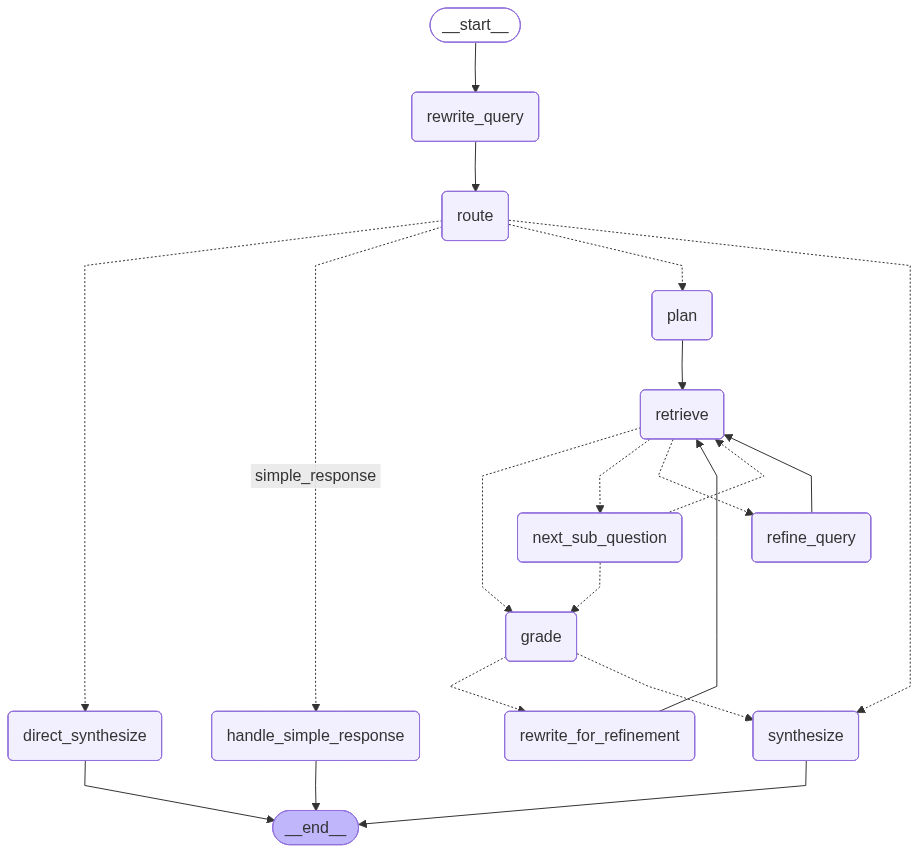

In [12]:
graph

In [13]:
pipeline = GraphPipeline(graph, short_term_memory=short_term)

In [20]:
chat1 = await pipeline.chat(
    user_message="Details about transformer",
    session_id="68275139-56cb-44d2-86a3-2ad7a29510e8",
    user_id="14684",
)

21:58:58.681 llm.complete


CancelledError: 